<a href="https://www.kaggle.com/code/ahmedfakhar123/ml-28-linear-regression-intuition-code?scriptVersionId=341940094" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

---
# 🤖 ML 28 — Linear Regression: Intuition & Code

### **Understanding how Linear Regression finds the best-fit line to predict continuous values.**

---


# 📈 What is Linear Regression?

**Linear Regression** is a supervised machine learning algorithm used to predict a **continuous numerical target** based on one or more input features.

For example:

* 🏠 House size → House price
* 📚 Study hours → Exam score
* 🚗 Car age → Car price
* 📢 Advertising budget → Sales

The basic idea is simple:

> **Find the line that best represents the relationship between the input and target, then use that line to make predictions.**

---

# 🧠 Linear Regression Intuition

Suppose we have data showing **hours studied** and **exam scores**:

| Hours Studied | Score |
| ------------: | ----: |
|             1 |    45 |
|             2 |    50 |
|             3 |    58 |
|             4 |    65 |
|             5 |    72 |

If we plot these points, they generally follow an upward trend.

Linear Regression tries to find a line that passes **as close as possible to all the data points**.

The line is called the **regression line** or **best-fit line**.



---

# 📐 Equation of Linear Regression

For a single feature, Linear Regression can be represented as:

$$
\hat{y} = b_0 + b_1x
$$

Where:

| Symbol    | Meaning             |
| --------- | ------------------- |
| $\hat{y}$ | Predicted value     |
| $b_0$     | Intercept           |
| $b_1$     | Slope / coefficient |
| $x$       | Input feature       |

### Example

If:

$$
\hat{y} = 40 + 6x
$$

Then for **5 hours of study**:

$$
\hat{y} = 40 + 6(5) = 70
$$

So the predicted score is **70**.

---

# 🎯 What Does "Best Fit" Mean?

The model needs to determine the values of:

* **Intercept ($b_0$)**
* **Coefficient ($b_1$)**

that produce the best predictions.

For every training example, we can calculate the difference between the actual and predicted value:

$$
Error = y - \hat{y}
$$

This difference is called the **residual**.

The goal is to find a line where these errors are as small as possible.

---

# 📉 Ordinary Least Squares (OLS)

Linear Regression commonly uses the **Ordinary Least Squares (OLS)** approach.

It minimizes the **sum of squared residuals**:

$$
\text{Cost} = \sum_{i=1}^{n}(y_i-\hat{y}_i)^2
$$

Why square the errors?

1. Positive and negative errors don't cancel each other.
2. Larger errors receive greater penalty.
3. It gives us a convenient mathematical optimization problem.

The line that minimizes this value is considered the **best-fit line**.

---

# 🔍 Simple vs Multiple Linear Regression

### 1. Simple Linear Regression

Uses **one input feature**:

$$
\hat{y} = b_0 + b_1x
$$

Example:

> Study Hours → Exam Score

### 2. Multiple Linear Regression

Uses **multiple features**:

$$
\hat{y} = b_0 + b_1x_1 + b_2x_2 + \cdots + b_nx_n
$$

Example:

> House Size + Bedrooms + Location → House Price



---
# 📥 Importing Data

In [1]:
import pandas as pd

df = pd.read_csv("/kaggle/input/datasets/nikhil7280/student-performance-multiple-linear-regression/Student_Performance.csv",
                usecols=["Hours Studied", "Performance Index"])
df

,Hours Studied,Performance Index
0,7,91.0
1,4,65.0
2,8,45.0
3,5,36.0
4,7,66.0
...,...,...
9995,1,23.0
9996,7,58.0
9997,6,74.0
9998,9,95.0


---

# ⚙️ Building a Simple Linear Regression Model

Now that we understand the intuition behind Linear Regression, let's build a Simple Linear Regression model using Scikit-learn.

Our goal is to predict Performance Index using only Hours Studied.

### Workflow

```text
Training Data
     ↓
Choose Features (X) and Target (y)
     ↓
Fit Linear Regression Model
     ↓
Learn Coefficients & Intercept
     ↓
Make Predictions
     ↓
Evaluate Predictions
```

In Scikit-learn, the implementation is straightforward:



## 1️⃣ Preparing the Data

We use:

* `Hours Studied` → Feature (`X`)
* `Performance Index` → Target (`y`)

In [2]:
from sklearn.model_selection import train_test_split

X = df[["Hours Studied"]]
y = df["Performance Index"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## 2️⃣ Training the Model

We can now create and train our Linear Regression model.

In [3]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [4]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [5]:
mean_absolute_error(y_test, y_pred)

15.53389374342778

In [6]:
mse = mean_squared_error(y_test, y_pred)
mse

321.8145383172104

In [7]:
import numpy as np
np.sqrt(mse)

np.float64(17.93919001285204)

In [8]:
r2_score(y_test, y_pred)

0.13160425385996788

The model achieves an R² score of approximately 0.132, meaning that Hours Studied alone explains only a small portion of the variation in Performance Index.

This makes sense because a student's performance depends on more than just study hours.

## 3️⃣ Understanding the Learned Parameters

Linear Regression learns two important parameters:

* `m` → slope / coefficient
* `b` → intercept

In [9]:
m = model.coef_

In [10]:
b = model.intercept_

In [11]:
m, b

(array([2.78430044]), np.float64(41.436634826535744))

## 4️⃣ Visualizing the Regression Line

Let's visualize the data and the best-fit regression line.

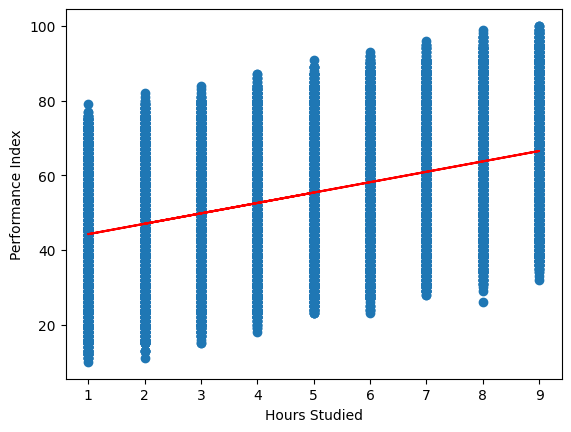

In [12]:
import matplotlib.pyplot as plt

plt.scatter(X, y)

plt.plot(
    X_train,
    model.predict(X_train),
    color="red"
)

plt.xlabel("Hours Studied")
plt.ylabel("Performance Index")

plt.show()

The blue points represent the actual observations, while the red line represents the relationship learned by the Linear Regression model.




---

# 📊 Important Terms

| Term              | Meaning                                       |
| ----------------- | --------------------------------------------- |
| **Feature (X)**   | Input variable used for prediction            |
| **Target (y)**    | Value we want to predict                      |
| **Coefficient**   | Effect of a feature on the prediction         |
| **Intercept**     | Predicted value when all features are zero    |
| **Prediction**    | Value produced by the model                   |
| **Residual**      | Difference between actual and predicted value |
| **Best-fit line** | Line minimizing squared residuals             |


---
# 🧑‍💻 Linear Regression From Scratch

Scikit-learn makes Linear Regression easy to use, but it's useful to understand what happens under the hood.

We'll create a simple Linear Regression class using the mathematical formulas for the slope and intercept.

In [13]:
class MyLinearRegression:

    def __init__(self):
        self.m = None
        self.b = None

    def fit(self, X_train, y_train):

        num = 0
        den = 0

        x_mean = X_train.mean().iloc[0]
        y_mean = y_train.mean()

        for i in range(X_train.shape[0]):
            x = X_train.iloc[i, 0]
            y = y_train.iloc[i]

            num += (x - x_mean) * (y - y_mean)
            den += (x - x_mean) ** 2

        self.m = num / den
        self.b = y_mean - self.m * x_mean

    def predict(self, X_test):
        return self.m * X_test.iloc[:, 0] + self.b

## Train the custom model

In [14]:
my_model = MyLinearRegression()

In [15]:
my_model.fit(X_train, y_train)

## Make predictions

In [16]:
my_y_pred = my_model.predict(X_test)

## Evaluate our implementation

In [17]:
r2_score(y_test, my_y_pred)

0.13160425385996788

# 🎯 Conclusion

In this notebook, we explored **Simple Linear Regression** and understood how it learns a straight line to predict a continuous target from a single feature.

### What we covered:

* 📈 Understanding the intuition behind Linear Regression
* 📐 Learning the **slope, intercept, and regression equation**
* 🤖 Building a model using **Scikit-learn**
* 📊 Visualizing the **best-fit regression line**
* 🧮 Evaluating the model using **R² Score**
* 🧑‍💻 Implementing Linear Regression **from scratch**
* 🔍 Comparing our implementation with Scikit-learn

Our from-scratch implementation achieved the **same R² score** as Scikit-learn, showing that we understand the core mathematics behind the algorithm.

> **Key takeaway:** Linear Regression is simple, but it provides the foundation for understanding more advanced machine learning models and optimization techniques.

---

## 🚀 What's Next?

In the next notebook, we'll move from **one feature** to **multiple features** and explore:

[**🤖 ML 29 — Multiple Linear Regression**](https://www.kaggle.com/code/ahmedfakhar123/ml-28-multiple-linear-regression)

This will show how multiple variables can work together to make better predictions.
